In [3]:
import pandas as pd

df = pd.read_csv("../data/data.csv", encoding="ISO-8859-1")

df = df.dropna(subset=['CustomerID'])
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

df['Sales'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [4]:
customer_revenue = (
    df.groupby('CustomerID')['Sales']
      .sum()
      .reset_index()
)

customer_revenue.columns = ['CustomerID', 'TotalRevenue']

customer_revenue.head()

,CustomerID,TotalRevenue
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [5]:
top_customers = customer_revenue.sort_values(
    by='TotalRevenue',
    ascending=False
)

top_customers.head(10)

,CustomerID,TotalRevenue
1690,14646.0,280206.02
4202,18102.0,259657.30
3729,17450.0,194550.79
3009,16446.0,168472.50
1880,14911.0,143825.06
55,12415.0,124914.53
1334,14156.0,117379.63
3772,17511.0,91062.38
2703,16029.0,81024.84
0,12346.0,77183.60


In [6]:
avg_cltv = customer_revenue['TotalRevenue'].mean()

print("Average CLTV:", round(avg_cltv, 2))

Average CLTV: 2053.79


In [7]:
aov = df['Sales'].sum() / df['InvoiceNo'].nunique()

print("Average Order Value (AOV):", round(aov, 2))

Average Order Value (AOV): 480.76


In [8]:
purchase_frequency = (
    df['InvoiceNo'].nunique()
    / df['CustomerID'].nunique()
)

print("Purchase Frequency:", round(purchase_frequency, 2))

Purchase Frequency: 4.27


In [9]:
cltv = aov * purchase_frequency

print("Customer Lifetime Value (CLTV):", round(cltv, 2))

Customer Lifetime Value (CLTV): 2053.79


In [10]:
top_customers = (
    df.groupby('CustomerID')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Sales, dtype: float64

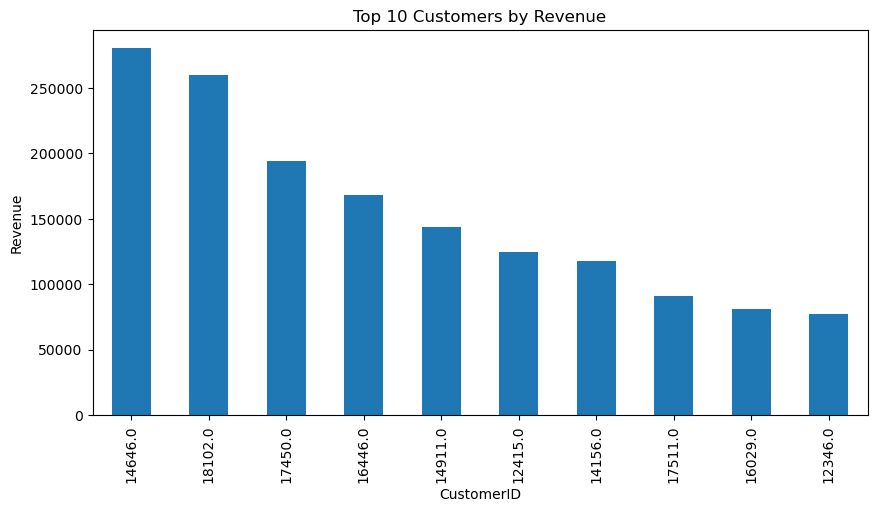

In [11]:
import matplotlib.pyplot as plt

top_customers.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Customers by Revenue")
plt.ylabel("Revenue")
plt.show()